---

# Coin Recognition using Classical Computer Vision and Machine Learning Approaches

---

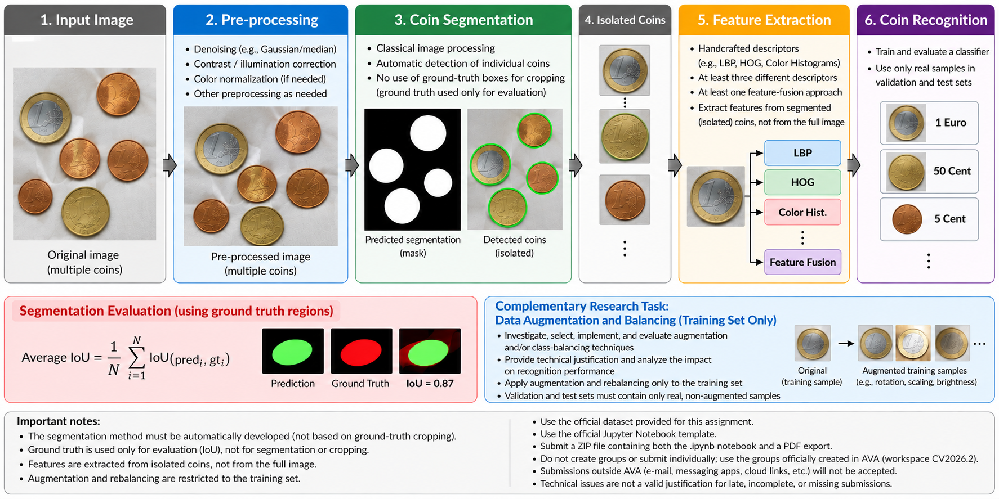



---



## Funções de auxílio

In [ ]:
# @Author: Prof. André Hochuli
# Auxiliary Function to plot side by side
def plot_sidebyside(img_list, titles, colormap=None, figsize=(12,6)):
    n = len(img_list)
    figure, axis = plt.subplots(1, n, figsize=figsize)

    for i in range(n):
        axis[i].imshow(
            img_list[i],
            cmap=colormap[i] if colormap else None
        )
        axis[i].set_title(titles[i])
        axis[i].axis('off')

    plt.show()

In [ ]:
from sklearn import metrics
import matplotlib.pyplot as plt

# @Author: Prof. André Hochuli
# *Adaptada => compila os resultados para analises qualitativas e quantitativas
def performance_evaluation(samples_to_plot, y_true, predictions, class_names, info_message):

    print(f"Evaluation of {info_message}")
    print(metrics.classification_report(y_true, predictions))


    # Matriz de confusão
    disp = metrics.ConfusionMatrixDisplay.from_predictions(y_true, predictions)
    disp.figure_.suptitle("Confusion Matrix")
    plt.show()

    # Imagens classificadas corretamente
    correct_idx = np.where(y_true == predictions)[0]
    n_correct = min(10, len(correct_idx))
    if n_correct > 0:
        plt.figure(figsize=(22, 4))
        for i in range(n_correct):
            idx = correct_idx[i]
            plt.subplot(1, n_correct, i+1)
            plt.imshow(samples_to_plot[idx]['crop'], cmap='gray', interpolation='nearest')
            plt.axis('off')
            plt.title(f"Lbl:{y_true[idx]} Pred:{predictions[idx]}")
        plt.suptitle("Correct Predictions", fontsize=16, fontweight='bold', color='white', backgroundcolor='green')
        plt.show()

    #Imagens classificadas incorretamente
    wrong_idx = np.where(y_true != predictions)[0]
    n_wrong = min(10, len(wrong_idx))
    if n_wrong > 0:
        plt.figure(figsize=(22, 4))
        for i in range(n_wrong):
            idx = wrong_idx[i]
            plt.subplot(1, n_wrong, i+1)
            plt.imshow(samples_to_plot[idx]['crop'], cmap='gray', interpolation='nearest')
            plt.axis('off')
            plt.title(f"Lbl:{y_true[idx]} Pred:{predictions[idx]}")
        plt.suptitle("Wrong Predictions", fontsize=16, fontweight='bold', color='white', backgroundcolor='red')
        plt.show()


    #Exibir exemplo de cada classe
    unique_classes = np.unique(y_true)
    plt.figure(figsize=(22, 4))
    for i, cls in enumerate(unique_classes):
        idx = np.where(y_true == cls)[0][0]  # primeiro índice da classe
        plt.subplot(1, len(unique_classes), i+1)
        plt.imshow(samples_to_plot[idx]['crop'], cmap='gray', interpolation='nearest')
        plt.axis('off')
        plt.title(f"{i}-{class_names[cls]}")
    plt.suptitle("Example of each class", fontsize=16, fontweight='bold', color='black', backgroundcolor='yellow')
    plt.show()

## Importar bibliotecas e *dataset*

In [ ]:
# Importar bibliotecas
import cv2
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from collections import Counter
from google.colab.patches import cv2_imshow
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import GroupShuffleSplit
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from skimage.feature import hog, local_binary_pattern

In [ ]:
!wget https://github.com/andrehochuli/teaching/raw/refs/heads/main/datasets/EuroCoins.zip -O EuroCoins.zip

--2026-09-11 22:08:02--  https://github.com/andrehochuli/teaching/raw/refs/heads/main/datasets/EuroCoins.zip
Resolving github.com (github.com)... 20.29.134.23
Connecting to github.com (github.com)|20.29.134.23|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/andrehochuli/teaching/refs/heads/main/datasets/EuroCoins.zip [following]
--2026-09-11 22:08:02--  https://raw.githubusercontent.com/andrehochuli/teaching/refs/heads/main/datasets/EuroCoins.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11142098 (11M) [application/zip]
Saving to: ‘EuroCoins.zip’

EuroCoins.zip       100%[===================>]  10.62M  --.-KB/s    in 0.08s   

2026-09-11 22:08:03 (126 MB/s) - ‘EuroCoins.zip’ saved [111420

In [ ]:
!unzip -qo EuroCoins.zip -d EuroCoins

In [ ]:
# Importar o dataset
image_dir = '/content/EuroCoins/images'
label_dir = '/content/EuroCoins/labels'

class_names = {
    0: '1 Cent',
    1: '2 Cent',
    2: '5 Cent',
    3: '10 Cent',
    4: '20 Cent',
    5: '50 Cent',
    6: '1 Euro',
    7: '2 Euro'
}

# Carregar imagens
image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

image_files.sort()

# 1. Pre-processing

Implement and evaluate the **image pre-processing and coin segmentation pipeline**.

* Apply appropriate **image enhancement/pre-processing** techniques when necessary.
* Develop a **classical image-processing strategy** to automatically detect and segment individual coins.
* Evaluate segmentation using the **average IoU** against the provided ground truth. **Ground-truth regions must be used only for evaluation, not for segmentation or cropping.**
* Provide representative **qualitative examples** of correct and incorrect segmentations and briefly discuss the observed behavior.



**Observações - Desafios encontrados no dataset:**

* fundos com diferentes características (plano e claro, textura de madeira, fundos com cores azuis e vermelho fortes)
* sobreposição de moedas
* fotos em diferentes ângulos

**Pipeline de pré-processamento e segmentação:**

`Grayscale → Median Filter → Hough Circle Transform`

Inicialmente, as imagens são convertidas para escala grayscale para reduzir a dimensionalidade dos dados e eliminar informações de cor que não são necessárias para a detecção circular das moedas.

Aplicou-se o Median Filter em razão de conseguir conciliar a redução e suavização de ruídos e preservação de bordas na imagem. Importante pela próxima etapa depender da identificação de contornos. Uma suavização excessiva poderia enfraquecer essas bordas e prejudicar a detecção, enquanto a ausência de filtragem poderia aumentar a ocorrência de bordas causadas por ruído, reflexos ou texturas do fundo.

O Hough Circles já aplica informação de gradiente e detecção de bordas (com Canny) uma técnica do OpenCV que é comumente aplicada para identificar formas circulares geométricas conhecidas em imagens. Assim, dispensando a necessidade de aplicação prévia destas técnicas, que podem piorar o seu desempenho.

In [ ]:
def segment_coins(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.medianBlur(gray, 9)
    h, w = gray.shape
    circles = cv2.HoughCircles(
        blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=65,
        param1=60, param2=40, minRadius=35, maxRadius=100
    )
    # Retorna uma lista de (x, y, r) círculos em coordenadas em pixel
    if circles is None:
        return []
    return [(float(x), float(y), float(r)) for x, y, r in circles[0]]

def circle_to_box(c):
    x, y, r = c
    return (x - r, y - r, x + r, y + r)

def iou(boxA, boxB):
    xA, yA = max(boxA[0], boxB[0]), max(boxA[1], boxB[1])
    xB, yB = min(boxA[2], boxB[2]), min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0

In [ ]:
def ground_truth_boxes(name):
    img = os.path.splitext(name)[0]
    lp = os.path.join(label_dir, img + '.txt')
    boxes = []
    if not os.path.exists(lp):
        return boxes
    img = cv2.imread(os.path.join(image_dir, name))
    h, w = img.shape[:2]
    with open(lp) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            cls, xc, yc, bw, bh = line.split()
            cls = int(cls); xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
            x1 = (xc - bw / 2) * w; y1 = (yc - bh / 2) * h
            x2 = (xc + bw / 2) * w; y2 = (yc + bh / 2) * h
            boxes.append((cls, x1, y1, x2, y2))
    return boxes

IOU_MATCH_THRESH = 0.5
matches_por_imagem = {}
ious = []

for name in image_files:
    img = cv2.imread(os.path.join(image_dir, name))
    gt = ground_truth_boxes(name)
    dets = segment_coins(img)
    used = set()
    matches = []
    for cls, *gbox in gt:
        best_iou, best_j = 0, -1
        for j, c in enumerate(dets):
            if j in used:
                continue
            v = iou(gbox, circle_to_box(c))
            if v > best_iou:
                best_iou, best_j = v, j
        if best_j >= 0 and best_iou > 0:
            used.add(best_j)
            matches.append((cls, gbox, dets[best_j], best_iou))
            ious.append(best_iou)
        else:
            matches.append((cls, gbox, None, 0.0))
            ious.append(0.0)
    matches_por_imagem[name] = matches

n_gt = len(ious)
n_correct = sum(1 for i in ious if i >= IOU_MATCH_THRESH)
print(f"Total de moedas ground-truth: {n_gt}")
print(f"IoU Médio: {np.mean(ious):.4f}")
print(f"Moedas segmentadas corretamente (IoU >= {IOU_MATCH_THRESH}): {n_correct}/{n_gt} ({100*n_correct/n_gt:.1f}%)")


Total de moedas ground-truth: 336
IoU Médio: 0.9143
Moedas segmentadas corretamente (IoU >= 0.5): 334/336 (99.4%)


In [ ]:
CROP_SIZE = 128

def crop_coin(img, c):
    x, y, r = c
    h, w = img.shape[:2]
    x1, y1 = max(0, int(x - r)), max(0, int(y - r))
    x2, y2 = min(w, int(x + r)), min(h, int(y + r))
    if x2 <= x1 or y2 <= y1:
        return None
    crop = cv2.resize(img[y1:y2, x1:x2].copy(), (CROP_SIZE, CROP_SIZE))
    mask = np.zeros((CROP_SIZE, CROP_SIZE), dtype=np.uint8)
    cv2.circle(mask, (CROP_SIZE // 2, CROP_SIZE // 2), CROP_SIZE // 2, 255, -1)
    return cv2.bitwise_and(crop, crop, mask=mask)

samples = []
for name in image_files:
    img = cv2.imread(os.path.join(image_dir, name))
    for cls, gbox, det, iou_v in matches_por_imagem[name]:
        if det is not None and iou_v >= IOU_MATCH_THRESH:
            crop = crop_coin(img, det)
            if crop is not None:
                samples.append({'crop': crop, 'label': cls, 'source': name})

print(f"Total de moedas: {len(samples)}")
print("Distribuição de classes:", Counter(s['label'] for s in samples))

Total de moedas: 334
Distribuição de classes: Counter({2: 56, 1: 51, 4: 50, 6: 49, 0: 41, 3: 32, 7: 28, 5: 27})


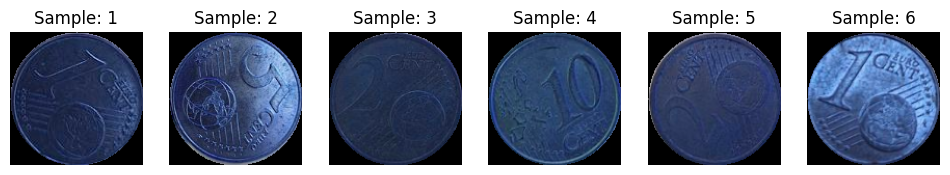

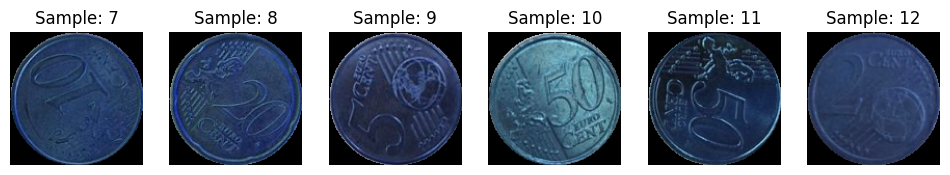

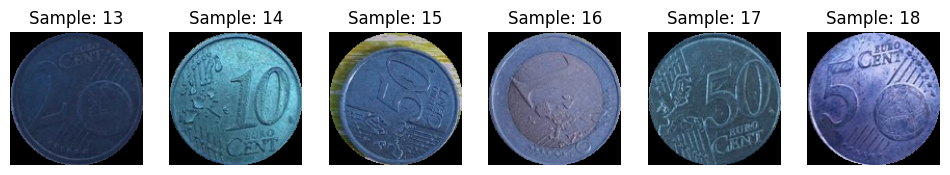

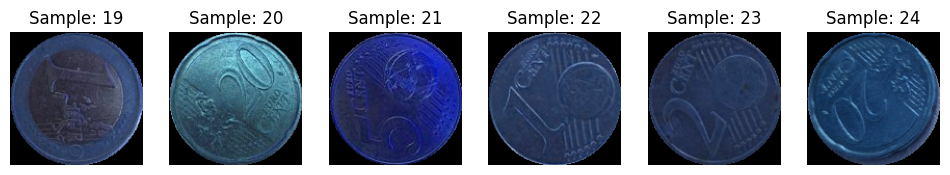

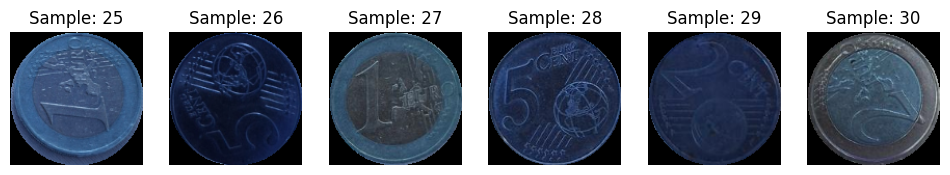

...

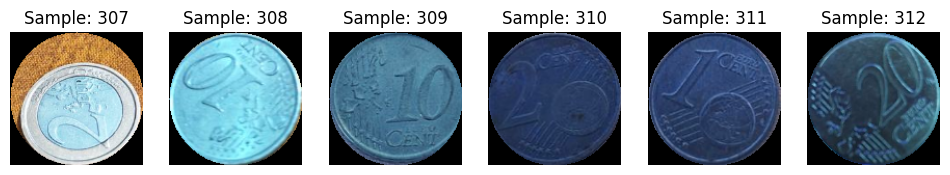

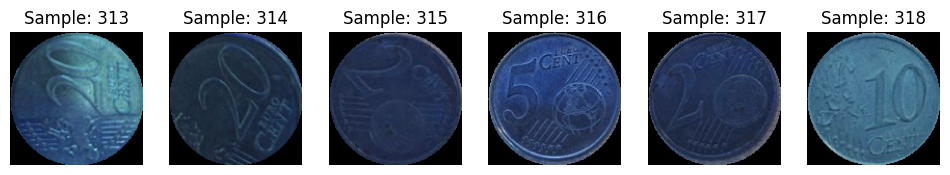

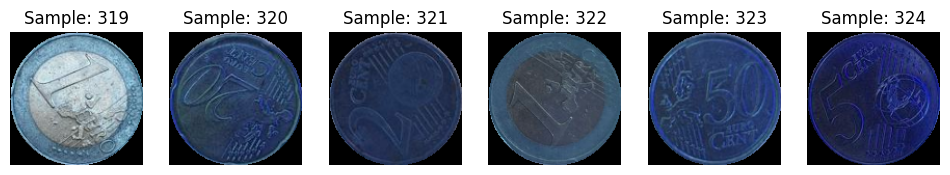

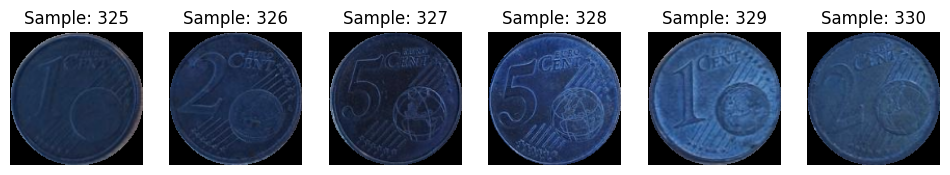

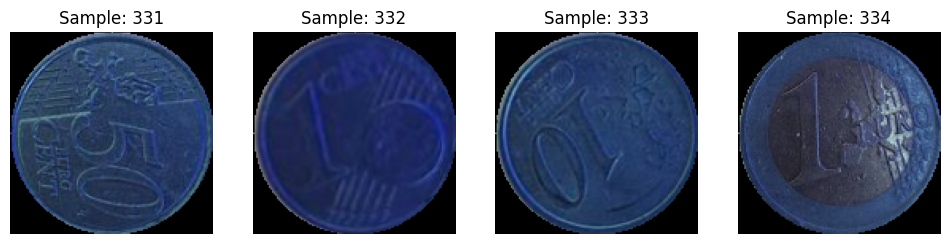

In [ ]:
# visualizar moedas após cropping
num = 6
for idx_crop in range(0, len(samples), num):
    batch = samples[idx_crop:idx_crop + num]
    samples_display = [sample["crop"] for sample in batch]
    titles = [f"Sample: {idx_crop + i + 1}" for i in range(len(batch))]
    cmaps = ["gray" for _ in range(len(batch))]
    plot_sidebyside(samples_display, titles, cmaps)

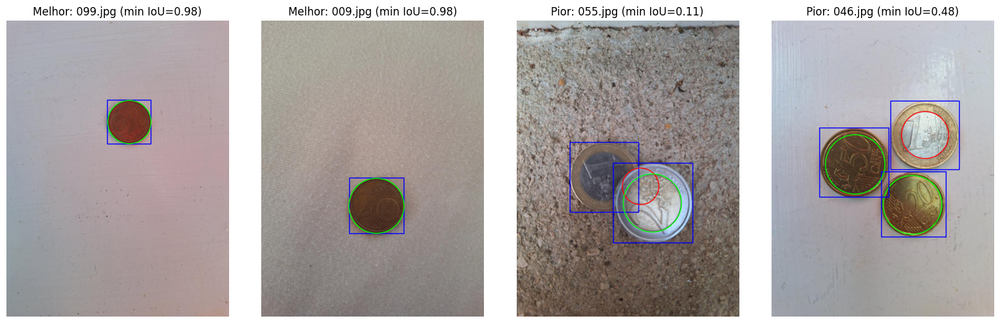

- Azul = ground truth box
- Verde = detecção correta (IoU>=0.5)
- Vermelho = detecção falha


In [ ]:
def draw_matches(name, matches):
    img = cv2.imread(os.path.join(image_dir, name))
    vis = img.copy()
    for cls, gbox, det, iou_v in matches:
        x1, y1, x2, y2 = map(int, gbox)
        cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
        if det is not None:
            x, y, r = det
            color = (0, 255, 0) if iou_v >= IOU_MATCH_THRESH else (0, 0, 255)
            cv2.circle(vis, (int(x), int(y)), int(r), color, 2)
    return cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

# rank de imagens por IoU
image_min_iou = {name: min([m[3] for m in matches], default=1.0)
                  for name, matches in matches_por_imagem.items()}
best_examples = sorted(image_min_iou, key=image_min_iou.get, reverse=True)[:2]
worst_examples = sorted(image_min_iou, key=image_min_iou.get)[:2]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, name in zip(axes[:2], best_examples):
    ax.imshow(draw_matches(name, matches_por_imagem[name]))
    ax.set_title(f"Melhor: {name} (min IoU={image_min_iou[name]:.2f})")
    ax.axis('off')
for ax, name in zip(axes[2:], worst_examples):
    ax.imshow(draw_matches(name, matches_por_imagem[name]))
    ax.set_title(f"Pior: {name} (min IoU={image_min_iou[name]:.2f})")
    ax.axis('off')
plt.tight_layout()
plt.show()
print("- Azul = ground truth box\n- Verde = detecção correta (IoU>=0.5)\n- Vermelho = detecção falha")


## Feature Extraction and Data Augmentation

Implement the feature extraction steps required to represent the **segmented/isolated coins** for classification.

* Evaluate at least **three handcrafted feature descriptors** (e.g., LBP, HOG, Color Histograms).
* Evaluate at least **one feature-fusion strategy** combining multiple descriptors.
* Apply and evaluate appropriate **data augmentation and/or class-balancing strategies** on the **training set only**.
* Briefly justify the selected descriptors and augmentation strategies, and discuss their expected contribution to recognition performance.
* **Features must be extracted from segmented/isolated coins, not from the full original images.**


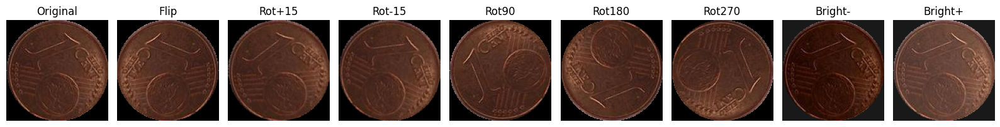

In [ ]:
# Data augmentation
def augment_crop(crop):
    # flip
    variants = [cv2.flip(crop, 1)]
    h, w = crop.shape[:2]
    center = (w // 2, h // 2)
    # realiza rotações em 15, -15, 90, 180 e 270 graus
    for angle in [15, -15, 90, 180, 270]:
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        variants.append(cv2.warpAffine(crop, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0)))
    # variações em brilho em -25 e +25
    for beta in [-25, 25]:
        variants.append(cv2.convertScaleAbs(crop, alpha=1.0, beta=beta))
    return variants

# Balanceamento e augmentation
def balance_and_augment(samples_train, target_per_class=None):
    by_class = defaultdict(list)
    for s in samples_train:
        by_class[s['label']].append(s)
    if target_per_class is None:
        target_per_class = max(len(v) for v in by_class.values())
    output = []
    for label, items in by_class.items():
        output.extend(items)
        current_count = len(items)
        sample_idx = 0
        variant_idx = 0
        i = 0
        # gerar novas imagens até atingir o alvo, para balancear
        while current_count < target_per_class:
            original_sample = items[sample_idx % len(items)]
            variants = augment_crop(original_sample["crop"])
            augmented_crop = variants[variant_idx % len(variants)]
            # cria novas amostras
            new_sample = {**original_sample, "crop": augmented_crop, "augmented": True}
            output.append(new_sample)
            current_count += 1
            variant_idx += 1
            if (variant_idx % len(variants) == 0):
                sample_idx += 1 # variante da classe

    return output

# Visualizar operações de augmentation
example = samples[0]
variants = augment_crop(example['crop'])
fig, axes = plt.subplots(1, len(variants) + 1, figsize=(16, 3))
axes[0].imshow(cv2.cvtColor(example['crop'], cv2.COLOR_BGR2RGB)); axes[0].set_title('Original'); axes[0].axis('off')
titles = ['Flip', 'Rot+15', 'Rot-15', 'Rot90', 'Rot180', 'Rot270', 'Bright-', 'Bright+']
for ax, v, t in zip(axes[1:], variants, titles):
    ax.imshow(cv2.cvtColor(v, cv2.COLOR_BGR2RGB)); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# Local Binary Pattern (LBP)
def lbp(img, P=24, R=3):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P, R, method='uniform')
    n_bins = P + 2
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist.astype(np.float32)

# Histogram of Oriented Gradients (HOG)
def HOG(img):
    gray = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), (96, 96))
    return hog(gray, orientations=9, pixels_per_cell=(8,8),cells_per_block=(2, 2), block_norm='L2-Hys', feature_vector=True).astype(np.float32)

# Color Histogram
def color_hist(img, bins=16):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(img, (1, 1, 1), (255, 255, 255))  # exclude masked-out background
    hists = []
    for ch in range(3):
        h = cv2.calcHist([hsv], [ch], mask, [bins], [0, 256])
        hists.append(cv2.normalize(h, h).flatten())
    return np.concatenate(hists).astype(np.float32)

# Feature Fusion das 3
def fusion_features(img):
    f_hog = HOG(img)
    f_lbp = lbp(img)
    f_color = color_hist(img)
    # normalização
    f_hog = f_hog / (np.linalg.norm(f_hog) + 1e-8)
    f_lbp = f_lbp / (np.linalg.norm(f_lbp) + 1e-8)
    f_color = f_color / (np.linalg.norm(f_color) + 1e-8)

    return np.concatenate([f_hog, f_lbp, f_color])

def extract_features(samples, feature_name):
    feats = []
    for sample in samples:
        img = sample["crop"]
        if feature_name == "HOG":
            feature = HOG(img)
        elif feature_name == "LBP":
            feature = lbp(img)
        elif feature_name == "Color":
            feature = color_hist(img)
        elif feature_name == "Fusion":
            feature = fusion_features(img)
        feats.append(feature)

    return np.array(feats)

In [ ]:
labels = np.array([s["label"] for s in samples])
groups = np.array([s["source"] for s in samples])
idx = np.arange(len(samples))

# Separar 80% dev (train+val) / 20% test
# GroupShuffleSplit -> moedas da mesma imagem original não sejam separadas, evitar vazamento
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
idx_dev, idx_test = next(gss.split(idx, labels, groups=groups))

dev_samples = [samples[i] for i in idx_dev]
test_samples = [samples[i] for i in idx_test]

print(f"Dev: {len(dev_samples)} | "f"Test: {len(test_samples)}")
print(f"Distribuição Dev: {Counter(s["label"] for s in dev_samples)}")
print(f"Distribuição Teste: {Counter(s["label"]for s in test_samples)}")

Dev: 266 | Test: 68
Distribuição Dev: Counter({2: 43, 1: 40, 6: 40, 4: 38, 0: 34, 3: 26, 7: 24, 5: 21})
Distribuição Teste: Counter({2: 13, 4: 12, 1: 11, 6: 9, 0: 7, 3: 6, 5: 6, 7: 4})


In [ ]:
# criar classificador
def create_model(classifier_name, config):
    if classifier_name == "SVM":
        return SVC(kernel="rbf", C=config["C"], gamma=config["gamma"])
    elif classifier_name == "Random Forest":
        return RandomForestClassifier(n_estimators=config["n_estimators"], max_depth=config["max_depth"], min_samples_split=config["min_samples_split"], random_state=42, n_jobs=-1)

# testes de hiperparâmetros
svm_configs = [
    {"C": 0.1, "gamma": "scale"},
    {"C": 1.0, "gamma": "scale"},
    {"C": 10.0, "gamma": "scale"},
    {"C": 100.0, "gamma": "scale"},
    {"C": 1.0, "gamma": 0.01},
    {"C": 10.0, "gamma": 0.01},
    {"C": 1.0, "gamma": 0.1},
    {"C": 10.0, "gamma": 0.1},
]

rf_configs = [
    {"n_estimators": 50, "max_depth": None, "min_samples_split": 2},
    {"n_estimators": 100, "max_depth": None, "min_samples_split": 2},
    {"n_estimators": 200, "max_depth": None, "min_samples_split": 2},
    {"n_estimators": 100, "max_depth": 10, "min_samples_split": 2},
    {"n_estimators": 100, "max_depth": 20, "min_samples_split": 2},
    {"n_estimators": 100, "max_depth": None, "min_samples_split": 5},
]



---



# Classification

Implement and evaluate the **shallow machine learning classification pipeline** using features extracted from the **segmented/isolated coins**.

* Evaluate at least **three handcrafted feature descriptors** and at least **one feature-fusion strategy**.
* Evaluate at least **two shallow classifiers** such as SVM, Random Forest, or KNN.
* Compare the different **feature–classifier combinations** using the defined train/validation/test protocol.
* Report appropriate metrics, including **Accuracy, Precision, Recall, F1-score, and confusion matrix**, and discuss the main results.


**Definição dos classificadores**

Foram escolhidos o SVM e o Random Forest porque são dois algoritmos de classificação clássicos que funcionam de maneiras diferentes. O SVM tenta encontrar uma separação entre as classes a partir das características extraídas das imagens, enquanto o Random Forest utiliza várias árvores de decisão para realizar a classificação. Como eles usam estratégias diferentes, é possível comparar qual deles se adapta melhor às características das moedas utilizadas no trabalho.

**Nested Cross-Validation**

A validação cruzada interna (inner CV - 3 folds) foi utilizada para selecionar a melhor combinação de descritor, classificador e hiperparâmetros com base no F1-score.
Ao passo que a validação cruzada externa (outer CV - 5 folds) foi utilizada para estimar o desempenho dessa estratégia de seleção em dados não utilizados na escolha do modelo. O aumento de dados foi aplicado exclusivamente às partições de treinamento de cada fold.

In [ ]:
y_dev = np.array([sample["label"] for sample in dev_samples])
groups_dev = np.array([sample["source"] for sample in dev_samples])

outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

feature_names = ["HOG", "LBP", "Color", "Fusion"]
classifier_names = ["SVM", "Random Forest"]

outer_results = []
selected_configs = []

# Nested Cross Validation
for outer_fold, (outer_train_idx, outer_val_idx) in enumerate(outer_cv.split(np.zeros(len(dev_samples)), y_dev, groups_dev), start=1):

    # separar outer train e outer validation
    outer_train_samples = [dev_samples[i] for i in outer_train_idx]
    outer_val_samples = [dev_samples[i] for i in outer_val_idx]

    y_outer_train = np.array([sample["label"] for sample in outer_train_samples])
    groups_outer_train = np.array([sample["source"] for sample in outer_train_samples])

    inner_results = []

    # testar combinação de features, modelo e hiperparâmetros
    for feature_name in feature_names:
        for classifier_name in classifier_names:
            if classifier_name == "SVM":
                configs = svm_configs
            else:
                configs = rf_configs

            for config in configs:
                inner_scores = []

                for (inner_train_idx, inner_val_idx) in inner_cv.split(np.zeros(len(outer_train_samples)), y_outer_train, groups_outer_train):
                    # balanceamento e augmentation somente no train
                    inner_train_samples = (balance_and_augment([outer_train_samples[i] for i in inner_train_idx]))
                    inner_val_samples = [outer_train_samples[i] for i in inner_val_idx]

                    X_inner_train = extract_features(inner_train_samples, feature_name)
                    X_inner_val = extract_features(inner_val_samples, feature_name)
                    y_inner_train = np.array([sample["label"] for sample in inner_train_samples])
                    y_inner_val = np.array([sample["label"] for sample in inner_val_samples])

                    model = create_model(classifier_name, config)
                    model.fit(X_inner_train, y_inner_train)

                    # validação interna
                    pred = model.predict(X_inner_val)
                    inner_f1 = f1_score(y_inner_val, pred, average="weighted", zero_division=0)
                    inner_scores.append(inner_f1)

                inner_results.append({
                    "Features": feature_name,
                    "Classifier": classifier_name,
                    "Config": config.copy(),
                    "Inner F1 Mean": np.mean(inner_scores),
                    "Inner F1 Std": np.std(inner_scores)
                })

    # melhor config inner cv
    inner_df = pd.DataFrame(inner_results)
    inner_df = inner_df.sort_values("Inner F1 Mean", ascending=False).reset_index(drop=True)

    best_inner = inner_df.iloc[0]
    best_feature = best_inner["Features"]
    best_classifier = best_inner["Classifier"]
    best_config = best_inner["Config"]

    print("\nMelhor configuração do Inner CV:")
    print(f"Feature: {best_feature}")
    print(f"Classificador: {best_classifier}")
    print(f"Configuração: {best_config}")
    print(f"Inner F1:{best_inner['Inner F1 Mean']:.4f}")


    # outer
    selected_configs.append({
        "Outer Fold": outer_fold,
        "Features": best_feature,
        "Classifier": best_classifier,
        "Config": best_config.copy(),
        "Inner F1": best_inner["Inner F1 Mean"]
    })

    # balanceamento e augmentation só no conjunto de treino
    outer_train_aug = (balance_and_augment(outer_train_samples))
    # melhor feature, modelo e hiperparametros no outer train
    X_outer_train = extract_features(outer_train_aug, best_feature)
    X_outer_val = extract_features(outer_val_samples, best_feature)

    y_outer_train_aug = np.array([sample["label"] for sample in outer_train_aug])
    y_outer_val = np.array([sample["label"] for sample in outer_val_samples])

    outer_model = create_model( best_classifier, best_config)
    outer_model.fit(X_outer_train, y_outer_train_aug)

    # validação no outer
    outer_pred = outer_model.predict(X_outer_val)
    accuracy = accuracy_score(y_outer_val, outer_pred)
    precision = precision_score(y_outer_val, outer_pred, average="weighted", zero_division=0)
    recall = recall_score(y_outer_val, outer_pred, average="weighted", zero_division=0)
    outer_f1 = f1_score(y_outer_val, outer_pred, average="weighted", zero_division=0)

    print(f"\nResultado do Outer Fold: {outer_fold}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {outer_f1:.4f}")

    outer_results.append({
        "Outer Fold": outer_fold,
        "Features": best_feature,
        "Classifier": best_classifier,
        "Config": best_config.copy(),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": outer_f1
    })

nested_results = pd.DataFrame(outer_results)
print("Resultados Nested Cross-Validation")
display(nested_results)

print("\nMédia dos Outer Folds:")
print(f"Accuracy: {nested_results['Accuracy'].mean():.4f} ± {nested_results['Accuracy'].std():.4f}")
print(f"Precision: {nested_results['Precision'].mean():.4f} ± {nested_results['Precision'].std():.4f}")
print(f"Recall: {nested_results['Recall'].mean():.4f} ± {nested_results['Recall'].std():.4f}")
print(f"F1-score: {nested_results['F1-score'].mean():.4f} ± {nested_results['F1-score'].std():.4f}")


Melhor configuração do Inner CV:
Feature: HOG
Classificador: SVM
Configuração: {'C': 10.0, 'gamma': 0.01}
Inner F1:0.7473

Resultado do Outer Fold: 1
Accuracy: 0.9216
Precision: 0.9277
Recall: 0.9216
F1-score: 0.9211

Melhor configuração do Inner CV:
Feature: HOG
Classificador: SVM
Configuração: {'C': 100.0, 'gamma': 'scale'}
Inner F1:0.7352

Resultado do Outer Fold: 2
Accuracy: 0.8361
Precision: 0.8654
Recall: 0.8361
F1-score: 0.8353

Melhor configuração do Inner CV:
Feature: HOG
Classificador: SVM
Configuração: {'C': 10.0, 'gamma': 0.01}
Inner F1:0.7936

Resultado do Outer Fold: 3
Accuracy: 0.8776
Precision: 0.8290
Recall: 0.8776
F1-score: 0.8493

Melhor configuração do Inner CV:
Feature: HOG
Classificador: SVM
Configuração: {'C': 10.0, 'gamma': 0.01}
Inner F1:0.8082

Resultado do Outer Fold: 4
Accuracy: 0.7458
Precision: 0.7533
Recall: 0.7458
F1-score: 0.7441

Melhor configuração do Inner CV:
Feature: HOG
Classificador: SVM
Configuração: {'C': 100.0, 'gamma': 'scale'}
Inner F1:0.79

,Outer Fold,Features,Classifier,Config,Accuracy,Precision,Recall,F1-score
0,1,HOG,SVM,"{'C': 10.0, 'gamma': 0.01}",0.921569,0.927669,0.921569,0.921080
1,2,HOG,SVM,"{'C': 100.0, 'gamma': 'scale'}",0.836066,0.865383,0.836066,0.835273
2,3,HOG,SVM,"{'C': 10.0, 'gamma': 0.01}",0.877551,0.828960,0.877551,0.849294
3,4,HOG,SVM,"{'C': 10.0, 'gamma': 0.01}",0.745763,0.753349,0.745763,0.744101
4,5,HOG,SVM,"{'C': 100.0, 'gamma': 'scale'}",0.869565,0.894410,0.869565,0.867671



Média dos Outer Folds:
Accuracy: 0.8501 ± 0.0658
Precision: 0.8540 ± 0.0670
Recall: 0.8501 ± 0.0658
F1-score: 0.8435 ± 0.0644


**Escolher melhores configurações**

A melhor configuração foi selecionada com base no F1-score obtido no conjunto de validação. Essa métrica foi utilizada por considerar conjuntamente precision e recall, permitindo uma comparação mais equilibrada entre as diferentes combinações de descritores e classificadores.

In [ ]:
# Seleção final do modelo
final_selection_results = []
for feature_name in feature_names:
    for classifier_name in classifier_names:
        if classifier_name == "SVM":
            configs = svm_configs
        else:
            configs = rf_configs

        for config in configs:
            scores = []
            for train_idx, val_idx in inner_cv.split(np.zeros(len(dev_samples)), y_dev, groups_dev):
                train_samples_fold = (balance_and_augment([dev_samples[i] for i in train_idx]))
                val_samples_fold = [dev_samples[i] for i in val_idx]

                X_train = extract_features(train_samples_fold, feature_name)
                X_val = extract_features(val_samples_fold, feature_name)

                y_train_fold = np.array([sample["label"] for sample in train_samples_fold])
                y_val_fold = np.array([sample["label"] for sample in val_samples_fold])

                model = create_model(classifier_name, config)
                model.fit(X_train, y_train_fold)
                pred = model.predict(X_val)

                score = f1_score(y_val_fold, pred, average="weighted", zero_division=0)
                scores.append(score)

            final_selection_results.append({
                "Features": feature_name,
                "Classifier": classifier_name,
                "Config": config.copy(),
                "F1 Mean": np.mean(scores),
                "F1 Std": np.std(scores)
            })

In [ ]:
# Melhor config final
final_selection_df = pd.DataFrame(final_selection_results)

final_selection_df = (final_selection_df.sort_values("F1 Mean", ascending=False).reset_index(drop=True))
display(final_selection_df)
best_final = (final_selection_df.iloc[0])
final_feature = best_final["Features"]
final_classifier = best_final["Classifier"]
final_config = best_final["Config"]

print("\nConfiguração final:")
print(f"Feature: {final_feature}")
print(f"Classificador: {final_classifier}")
print(f"Hiperparâmetros: {final_config}")
print(f"F1 médio na seleção: {best_final['F1 Mean']:.4f}")

,Features,Classifier,Config,F1 Mean,F1 Std
0,HOG,SVM,"{'C': 10.0, 'gamma': 0.01}",0.839896,0.024050
1,HOG,SVM,"{'C': 100.0, 'gamma': 'scale'}",0.829880,0.024286
2,HOG,SVM,"{'C': 10.0, 'gamma': 'scale'}",0.829880,0.024286
3,HOG,SVM,"{'C': 1.0, 'gamma': 'scale'}",0.786357,0.018935
4,HOG,SVM,"{'C': 10.0, 'gamma': 0.1}",0.762970,0.003348
5,Fusion,Random Forest,"{'n_estimators': 200, 'max_depth': None, 'min_...",0.749474,0.004924
6,Fusion,Random Forest,"{'n_estimators': 100, 'max_depth': None, 'min_...",0.746806,0.019202
7,HOG,Random Forest,"{'n_estimators': 200, 'max_depth': None, 'min_...",0.739181,0.020400
8,Fusion,Random Forest,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",0.732258,0.003366
9,HOG,SVM,"{'C': 1.0, 'gamma': 0.01}",0.731710,0.018134



Configuração final:
Feature: HOG
Classificador: SVM
Hiperparâmetros: {'C': 10.0, 'gamma': 0.01}
F1 médio na seleção: 0.8399


**Avaliação final**

Após a comparação dos modelos no conjunto de validação, a melhor combinação foi utilizada para realizar a avaliação final no conjunto de teste. Foram analisadas as métricas de desempenho e a matriz de confusão, além de exemplos de classificações corretas e incorretas.

Evaluation of HOG + SVM
              precision    recall  f1-score   support

           0       0.70      1.00      0.82         7
           1       1.00      0.91      0.95        11
           2       0.91      0.77      0.83        13
           3       0.75      1.00      0.86         6
           4       1.00      0.92      0.96        12
           5       0.86      1.00      0.92         6
           6       1.00      1.00      1.00         9
           7       1.00      0.50      0.67         4

    accuracy                           0.90        68
   macro avg       0.90      0.89      0.88        68
weighted avg       0.92      0.90      0.90        68



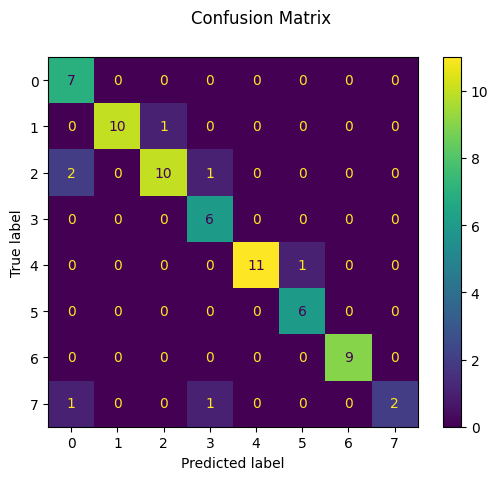

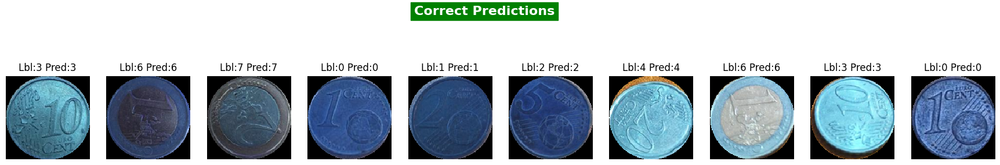

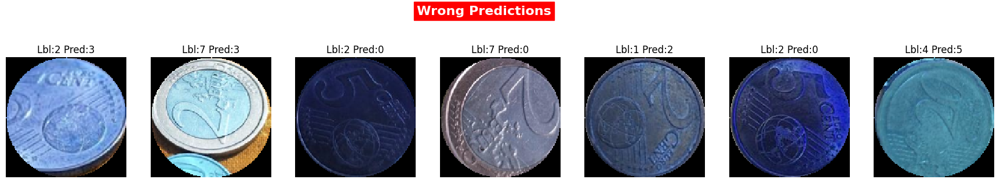

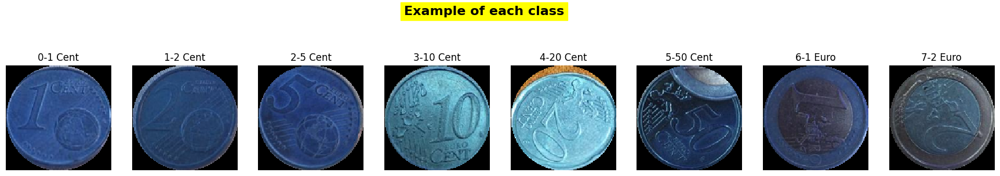

In [ ]:
# modelo final
samples_dev_aug = (balance_and_augment(dev_samples))

X_final_train = extract_features(samples_dev_aug, final_feature)
y_final_train = np.array([sample["label"] for sample in samples_dev_aug])

final_model = create_model(final_classifier, final_config)
final_model.fit(X_final_train, y_final_train)

X_test_final = extract_features(test_samples, final_feature)
y_test = np.array([sample["label"] for sample in test_samples])
y_pred = final_model.predict(X_test_final)

performance_evaluation(test_samples, y_test, y_pred, class_names, f"{final_feature} + {final_classifier}")

---

# Critical Analysis

* Produce a **technical report** describing the proposed solution, methodology, experimental protocol, results, and critical discussion.
* Report appropriate **quantitative metrics**, including **Accuracy, Precision, Recall, F1-score, confusion matrix, per-class performance, and average IoU for segmentation**.
* Provide **qualitative results**, showing representative **correct and incorrect segmentation and classification cases**, and discuss why they succeeded or failed.
* Discuss how errors across **pre-processing → segmentation → feature extraction → classification** propagate and affect final performance.
* Identify the main **limitations, failure cases, and potential improvements**, supporting conclusions with quantitative and qualitative evidence.



### Guiding Questions

The analysis should address the following guiding questions:

1. **What was the impact of image pre-processing and segmentation on the recognition pipeline?** Discuss segmentation quality, representative successes/failures, and its influence on subsequent feature extraction and recognition.

2. **What was the impact of data augmentation and/or class-balancing strategies?** Did these techniques improve sample diversity, class representation, and generalization?

3. **What was the contribution of each feature descriptor to coin recognition?** Which descriptors were most discriminative, and did **feature fusion** improve performance?

4. **How did the evaluated shallow classifiers differ in terms of recognition performance, computational cost, and robustness?**

5. **Which feature–classifier combination achieved the best coin-recognition performance?** Justify the selection quantitatively based on the defined evaluation protocol and metrics.

6. **What were the main failure cases and limitations of the complete pipeline?** Discuss potential sources of error across segmentation, feature extraction, and classification, and identify possible improvements.





---



## 1. Pré-processamento e segmentação

O pipeline seguiu as seguintes etapas sequenciais:

- Conversão para escala cinza (GrayScale)
- Aplicação de um filtro de mediana (MedianFilter)
- Detecção de formas circulares (HoughCircles)

Essa combinação atingiu um IoU médio de 0,9143 frente ao ground truth, com 334 das 336 moedas anotadas (99,4%) corretamente localizadas (IoU ≥ 0,5).

Os resultados quantitativos indicam que a estratégia de segmentação foi adequada para a maior parte do conjunto de dados. Nos exemplos de segmentação correta apresentados abaixo, as circunferências detectadas apresentam boa sobreposição com o ground truth, mostrando que a combinação entre o filtro de mediana e o HoughCircles é eficaz principalmente quando as moedas apresentam bordas bem definidas e formato aproximadamente circular.

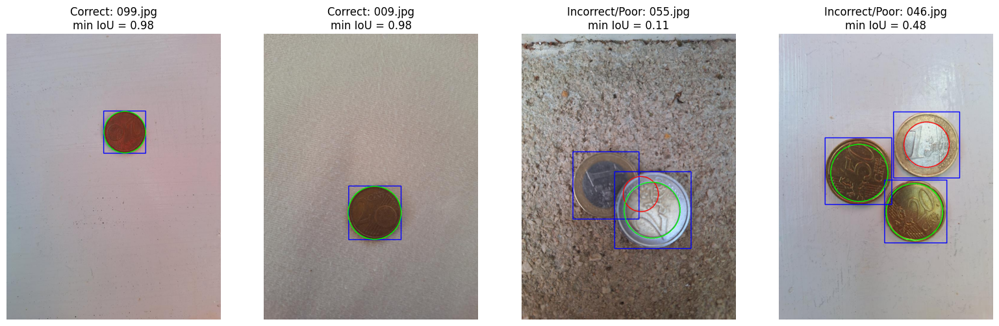

Blue = ground truth | Green = correct detection (IoU >= 0.5) | Red = poor detection (IoU < 0.5)


In [ ]:
# Exemplos qualitativos de segmentação

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, name in zip(axes[:2], best_examples):
    ax.imshow(draw_matches(name, matches_por_imagem[name]))
    ax.set_title(
        f"Correct: {name}\nmin IoU = {image_min_iou[name]:.2f}"
    )
    ax.axis("off")

for ax, name in zip(axes[2:], worst_examples):
    ax.imshow(draw_matches(name, matches_por_imagem[name]))
    ax.set_title(
        f"Incorrect/Poor: {name}\nmin IoU = {image_min_iou[name]:.2f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

print(
    "Blue = ground truth | "
    "Green = correct detection (IoU >= 0.5) | "
    "Red = poor detection (IoU < 0.5)"
)

Os dois casos com IoU abaixo do limiar de 0,5 foram:

- Em `055.jpg` (IoU = 0,11).
- Em `046.jpg` (IoU = 0,48, moeda de 1 Euro).

Nos exemplos com menor IoU, observa-se uma correspondência inferior entre a circunferência detectada e a anotação de referência. Em `055.jpg`, as moedas aparecem sobrepostas e sobre um fundo mais texturizado, e a circunferência detectada apresenta grande deslocamento em relação ao ground truth. Em `046.jpg`, embora o fundo seja mais uniforme, a circunferência estimada para a moeda de 1 Euro não cobre adequadamente toda a região anotada. Esses casos mostram uma limitação do HoughCircles quando a estrutura circular da moeda não é identificada com precisão.

Esse efeito também evidencia a importância da segmentação para as etapas seguintes do pipeline. De acordo com o critério adotado, as duas moedas com IoU abaixo de 0,5 não foram incluídas na avaliação de classificação (consideradas como moedas não identificadas).

Consequentemente, o desempenho de classificação reportado posteriormente corresponde às moedas que atenderam ao critério de segmentação utilizado. Dessa forma, os resultados de classificação devem ser interpretados em conjunto com o desempenho da segmentação, e não como uma medida completamente independente das etapas anteriores do pipeline.

## 2. Aumento de dados e balanceamento de classes

A distribuição das 334 moedas segmentadas era desbalanceada, variando de 27 amostras para a classe 50 Cent a 56 para a classe 5 Cent. Para reduzir esse efeito, foi aplicado aumento de dados exclusivamente às partições de treinamento, preservando os conjuntos de validação e teste sem modificações.

As transformações utilizadas foram:

- Flip horizontal
- Rotações de 15°, -15°, 90°, 180° e 270°
- Variações de brilho de ±25

Em cada fold de treinamento, as classes minoritárias foram aumentadas até atingir o número de amostras da classe mais frequente naquele fold. Dessa forma, o balanceamento foi realizado de maneira independente dentro de cada partição, evitando que imagens aumentadas derivadas de uma amostra de validação fossem utilizadas no treinamento.

A escolha dessas transformações é coerente com o problema, pois introduz variações de orientação e iluminação sem alterar a identidade da moeda. Isso aumenta a diversidade das amostras apresentadas ao classificador e reduz a influência do desbalanceamento original das classes.

Entretanto, não foi realizado um experimento controlado comparando o mesmo protocolo com e sem aumento de dados. Portanto, é possível afirmar que o procedimento aumentou a diversidade e equalizou a representação das classes durante o treinamento, mas não é possível quantificar isoladamente sua contribuição para a generalização final.

## 3. Contribuição dos descritores e da fusão

A comparação entre os descritores foi realizada utilizando o F1-score médio obtido na validação cruzada interna sobre o conjunto de desenvolvimento. Para cada combinação entre descritor e classificador, foi considerada a melhor configuração de hiperparâmetros encontrada.

| Features | Classificador | F1-score médio |
|---|---|---:|
| HOG | SVM | 0,8399 |
| Fusion | Random Forest | 0,7495 |
| HOG | Random Forest | 0,7392 |
| Fusion | SVM | 0,7054 |
| Color | Random Forest | 0,6006 |
| Color | SVM | 0,5710 |
| LBP | Random Forest | 0,5076 |
| LBP | SVM | 0,4154 |

O HOG foi o descritor mais discriminativo entre os avaliados. Sua melhor combinação, utilizando SVM, atingiu F1-score médio de 0,8399, enquanto o mesmo descritor com Random Forest obteve 0,7392. Esses resultados indicam que as informações de gradiente e orientação das bordas são particularmente relevantes para diferenciar as denominações das moedas.

Esse comportamento é coerente com a natureza visual do problema, já que grande parte das diferenças entre as classes está presente no relevo gravado, incluindo números, símbolos, contornos e padrões de forma. Como o HOG representa a distribuição espacial de gradientes, ele consegue capturar diretamente esse tipo de informação estrutural.

O histograma de cor apresentou desempenho intermediário, com melhor F1-score médio de 0,6006 utilizando Random Forest. Embora a cor contribua para distinguir alguns grupos de moedas, diferentes denominações podem compartilhar tonalidades semelhantes. Além disso, o histograma utilizado representa a distribuição global de cores, sem preservar sua posição espacial dentro da moeda. Decorrente da segmentação, uma parcela das imagens ficou com o fundo em evidência, o que pode ter tido influência nessa parte também.

O LBP apresentou o menor desempenho entre os descritores individuais, alcançando no máximo F1-score médio de 0,5076 com Random Forest. Isso indica que padrões locais de textura, isoladamente, não foram suficientemente discriminativos para separar as oito classes avaliadas.

A fusão de HOG, LBP e Color também não superou o HOG isolado. Sua melhor configuração, utilizando Random Forest, atingiu F1-score médio de 0,7495, aproximadamente 0,09 abaixo do resultado de HOG + SVM. Apesar de combinar diferentes fontes de informação, a simples concatenação dos descritores não produziu ganho de desempenho.

Esse resultado sugere que as informações adicionadas por LBP e Color não foram suficientemente complementares ao HOG para compensar o aumento da complexidade da representação. Como esses dois descritores apresentaram desempenho individual inferior, sua inclusão pode ter acrescentado características pouco discriminativas ou redundantes.

Portanto, entre os descritores avaliados, o HOG apresentou a contribuição mais relevante para o reconhecimento das moedas. A fusão de features não melhorou o desempenho neste experimento, indicando que estratégias mais sofisticadas, como seleção de features, ponderação entre descritores ou redução de dimensionalidade, poderiam ser exploradas futuramente.

## 4. Comparação entre os classificadores rasos avaliados

SVM e Random Forest foram escolhidos por representarem estratégias distintas de separação de classes: o primeiro busca uma superfície de decisão com margem máxima no espaço de features, enquanto o segundo agrega as decisões de múltiplas árvores.

O padrão observado nos resultados da seção 3 mostra que o SVM apresentou maior dependência da qualidade do descritor. Com HOG, sua melhor configuração atingiu F1-score médio de 0,8399, superando o Random Forest com o mesmo descritor, que obteve 0,7392. Por outro lado, com descritores menos discriminativos, como LBP e Color, o Random Forest apresentou resultados superiores ao SVM.

O Random Forest apresentou resultados relativamente mais estáveis entre diferentes representações, enquanto o SVM obteve o maior desempenho global quando associado ao descritor mais informativo. Isso sugere que, neste conjunto de dados, o SVM com kernel RBF consegue explorar de forma mais eficaz uma representação discriminativa como o HOG, enquanto o Random Forest apresentou menor variação de desempenho entre os diferentes descritores avaliados.

Além do desempenho de reconhecimento, foi realizada uma avaliação empírica do custo computacional com base nos tempos de treinamento e inferência observados durante o experimento nos cinco folds externos.

Nas configurações avaliadas pelo pipeline, o SVM apresentou tempo médio de treinamento de aproximadamente 0,30 s, enquanto o Random Forest apresentou aproximadamente 2,27 s. Em relação à inferência, o Random Forest apresentou tempo médio ligeiramente menor, com aproximadamente 1,16 ms por amostra, contra 1,49 ms do SVM.

Apesar dessa diferença, ambos os classificadores apresentaram tempos de predição da ordem de poucos milissegundos por amostra, indicando baixo custo de inferência no contexto do conjunto avaliado.

Como essa medição foi realizada utilizando as configurações selecionadas pelo pipeline experimental, os valores devem ser interpretados como uma comparação prática das soluções avaliadas, e não como uma análise isolada da complexidade computacional intrínseca de SVM e Random Forest.

Considerando conjuntamente os resultados de reconhecimento e os custos observados, o SVM associado ao HOG apresentou o melhor desempenho global e baixo custo de inferência, enquanto o Random Forest apresentou maior estabilidade entre descritores e uma pequena vantagem no tempo de predição por amostra.

In [ ]:
# Comparação de custo computacional
cost_results = []

best_svm = inner_df[inner_df["Classifier"] == "SVM"].iloc[0]
best_rf = inner_df[inner_df["Classifier"] == "Random Forest"].iloc[0]

best_svm_feature = best_svm["Features"]
best_svm_config = best_svm["Config"]

best_rf_feature = best_rf["Features"]
best_rf_config = best_rf["Config"]

for outer_fold, (train_idx, val_idx) in enumerate(outer_cv.split(np.zeros(len(dev_samples)), y_dev, groups_dev), start=1):

    train_samples = balance_and_augment([dev_samples[i] for i in train_idx])
    val_samples = [dev_samples[i] for i in val_idx]

    y_train = np.array([sample["label"] for sample in train_samples])
    y_val = np.array([sample["label"] for sample in val_samples])

    for classifier_name in ["SVM", "Random Forest"]:
        if classifier_name == "SVM":
            feature_name = best_svm_feature
            config = best_svm_config
        else:
            feature_name = best_rf_feature
            config = best_rf_config

        X_train = extract_features(train_samples, feature_name)
        X_val = extract_features(val_samples, feature_name)

        model = create_model(classifier_name, config)
        start = time.perf_counter()
        model.fit(X_train,y_train)
        train_time = time.perf_counter() - start

        start = time.perf_counter()
        pred = model.predict(X_val)
        pred_time = time.perf_counter() - start
        pred_per_sample = (pred_time / len(X_val)) * 1000

        cost_results.append({
            "Outer Fold": outer_fold,
            "Classifier": classifier_name,
            "Training Time (s)": train_time,
            "Prediction Time (s)": pred_time,
            "Prediction per Sample (ms)": pred_per_sample
        })

cost_df = pd.DataFrame(cost_results)
display(cost_df)

,Outer Fold,Classifier,Training Time (s),Prediction Time (s),Prediction per Sample (ms)
0,1,SVM,0.292633,0.076210,1.494322
1,1,Random Forest,3.138117,0.057521,1.127870
2,2,SVM,0.207820,0.063376,1.038944
3,2,Random Forest,1.860406,0.066156,1.084524
4,3,SVM,0.333072,0.095237,1.943613
5,3,Random Forest,2.281283,0.066082,1.348607
6,4,SVM,0.236370,0.066620,1.129149
7,4,Random Forest,2.070868,0.056889,0.964219
8,5,SVM,0.452638,0.084396,1.834701
9,5,Random Forest,2.012796,0.058026,1.261441


## 5. Melhor combinação e avaliação final no conjunto de teste

A melhor combinação selecionada no conjunto de desenvolvimento foi HOG + SVM com kernel RBF, utilizando `C = 10` e `gamma = 0.01`. Essa configuração apresentou F1-score médio de 0,8399 na validação cruzada interna utilizada para a seleção final do modelo.

A escolha também foi consistente com os resultados da Nested Cross-Validation. Nos cinco folds externos, a estratégia de seleção escolheu HOG + SVM em todos os casos, alcançando F1-score médio de 0,8435 ± 0,0644. A variação entre os folds, de 0,7441 a 0,9211, indica que o desempenho ainda apresenta sensibilidade à composição das partições, especialmente considerando o tamanho reduzido do conjunto de dados.

Após a seleção dos hiperparâmetros, o modelo final foi treinado utilizando todo o conjunto de desenvolvimento, com aumento de dados e balanceamento aplicados somente às amostras de treinamento. Em seguida, foi avaliado uma única vez no conjunto de teste independente, composto por 68 moedas que não participaram do treinamento nem da seleção do modelo.

No conjunto de teste, HOG + SVM atingiu acurácia de 0,90, F1-score ponderado de 0,90, precision ponderada de 0,92 e recall ponderado de 0,90.

| Classe | Precision | Recall | F1-score | Suporte |
|---|---:|---:|---:|---:|
| 1 Cent | 0,70 | 1,00 | 0,82 | 7 |
| 2 Cent | 1,00 | 0,91 | 0,95 | 11 |
| 5 Cent | 0,91 | 0,77 | 0,83 | 13 |
| 10 Cent | 0,75 | 1,00 | 0,86 | 6 |
| 20 Cent | 1,00 | 0,92 | 0,96 | 12 |
| 50 Cent | 0,86 | 1,00 | 0,92 | 6 |
| 1 Euro | 1,00 | 1,00 | 1,00 | 9 |
| 2 Euro | 1,00 | 0,50 | 0,67 | 4 |
| **Weighted avg** | **0,92** | **0,90** | **0,90** | **68** |

A classe 1 Euro apresentou o melhor desempenho, com precision, recall e F1-score iguais a 1,00. Também foram obtidos resultados elevados para 2 Cent, 20 Cent e 50 Cent, todos com F1-score acima de 0,90.

As maiores dificuldades ocorreram na classe 2 Euro, com F1-score de 0,67 e recall de 0,50, e nas classes 1 Cent e 5 Cent, com F1-scores de 0,82 e 0,83, respectivamente. No caso de 2 Euro, apenas duas das quatro amostras do conjunto de teste foram corretamente reconhecidas, de modo que o baixo suporte dessa classe torna sua métrica particularmente sensível a poucos erros individuais.

O desempenho no teste foi ligeiramente superior ao F1-score médio observado na Nested Cross-Validation externa. Entretanto, esse resultado não deve ser interpretado como evidência de que o modelo necessariamente generaliza melhor do que a estimativa obtida nos folds externos, pois o conjunto de teste representa apenas uma partição específica dos dados. A média e o desvio padrão da validação cruzada fornecem uma visão mais ampla da variabilidade esperada do desempenho.

## 6. Propagação de erros, limitações e casos de falha

A matriz de confusão do conjunto de teste mostra sete classificações incorretas, distribuídas entre algumas classes específicas. Os erros observados foram:

- 1 caso de 2 Cent classificado como 5 Cent;
- 2 casos de 5 Cent classificados como 1 Cent;
- 1 caso de 5 Cent classificado como 10 Cent;
- 1 caso de 20 Cent classificado como 50 Cent;
- 1 caso de 2 Euro classificado como 1 Cent;
- 1 caso de 2 Euro classificado como 10 Cent.

Os exemplos qualitativos de classificações corretas e incorretas apresentados anteriormente complementam a matriz de confusão e permitem observar algumas das condições em que o modelo obtém sucesso ou falha.

Os erros envolvendo moedas de mesma aparência geral são coerentes com as limitações dos descritores utilizados. O caso de 2 Cent classificado como 5 Cent ocorre entre moedas de cobre com características visuais semelhantes, enquanto a confusão entre 20 Cent e 50 Cent envolve moedas douradas com características de aparência próximas.

Os erros da classe 5 Cent também mostram que, mesmo utilizando HOG, variações presentes nas imagens podem modificar a representação dos gradientes. Como o descritor depende das bordas e orientações presentes no recorte, diferenças de iluminação, orientação ou enquadramento podem produzir features menos discriminativas.

A classe 2 Euro apresentou a maior dificuldade relativa, com recall de 0,50: apenas duas das quatro amostras dessa classe foram corretamente reconhecidas. Os dois erros foram classificações como 1 Cent e 10 Cent, classes visualmente bastante distintas de 2 Euro. Isso sugere que, nesses exemplos específicos, a representação obtida pelo HOG não preservou informação discriminativa suficiente para separar corretamente a classe. O baixo número de amostras de 2 Euro no teste também faz com que poucos erros tenham grande impacto sobre suas métricas.

Esses resultados evidenciam como erros ou limitações podem se propagar ao longo do pipeline. Uma segmentação imprecisa ou um recorte pouco representativo modifica a região utilizada na extração de features. Como o HOG depende diretamente da distribuição dos gradientes e das bordas presentes na imagem, alterações nessa região podem produzir uma representação menos discriminativa. O classificador recebe apenas essas features e, portanto, não consegue recuperar informações que tenham sido perdidas nas etapas anteriores.

Apesar do IoU médio elevado de 0,9143 e da localização adequada de 334 das 336 moedas segundo o limiar adotado, as duas moedas com IoU abaixo de 0,5 não foram incluídas na avaliação de classificação. Assim, o desempenho final de reconhecimento deve ser interpretado em conjunto com o resultado da etapa de segmentação.

As principais limitações observadas estão relacionadas ao tamanho reduzido do conjunto de dados e ao número limitado de exemplos por classe. No conjunto de teste, o suporte varia de apenas 4 a 13 amostras, fazendo com que poucos erros tenham grande impacto nas métricas individuais. Isso é particularmente evidente na classe 2 Euro.

Além disso, mesmo com a utilização de separação por grupos e Nested Cross-Validation, houve variação relevante entre os folds externos, com F1-score variando de 0,7441 a 0,9211 e média de 0,8435 ± 0,0644. Essa variação indica que o desempenho ainda depende da composição das partições e reforça a necessidade de avaliar a abordagem em um conjunto de dados maior.

Outra limitação está relacionada aos próprios descritores. O HOG apresentou o melhor desempenho, mas representa principalmente informações de gradientes e estrutura. O histograma de cor utilizado não preserva relações espaciais entre as cores, enquanto o LBP apresentou baixo poder discriminativo para esse problema. Isso limita a exploração de características que poderiam ser relevantes para determinadas denominações.

A fusão de features também foi realizada por concatenação direta de HOG, LBP e Color e não apresentou ganho de desempenho. Estratégias de seleção de features, redução de dimensionalidade ou ponderação entre descritores poderiam explorar de maneira mais eficiente informações complementares.

O aumento de dados corrigiu o desbalanceamento e aumentou a diversidade das amostras de treinamento, mas não foi realizado um experimento controlado comparando o pipeline com e sem augmentation. Dessa forma, sua contribuição isolada para a generalização não pode ser quantificada.

Por fim, o custo computacional foi avaliado empiricamente no ambiente de execução utilizado. Os tempos observados mostram que ambos os classificadores possuem baixo custo de inferência para este experimento, mas esses valores dependem do hardware, do ambiente de execução e das configurações selecionadas, não devendo ser interpretados como propriedades universais dos algoritmos.

Como possíveis melhorias, trabalhos futuros poderiam ampliar o conjunto de dados, incluir maior variedade de condições de iluminação, orientação e fundo, explorar representações que preservem a distribuição espacial das cores, aplicar seleção ou redução de dimensionalidade na fusão de features e avaliar estratégias alternativas de segmentação. Essas mudanças poderiam melhorar a estabilidade entre diferentes partições e reduzir erros de reconhecimento em classes com menor número de amostras.